# TP NOTÉ S3 — REGRESSION ENGINEERING CHALLENGE
## 4e année Option Développeur — 3 h — Ames Housing, Iowa (USA)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Contexte & dataset — 5 pts

Vous intervenez pour une équipe qui doit estimer le **prix de vente de logements à Ames, Iowa**. Le dataset Ames Housing provient de transactions immobilières de 2006 à 2010 et contient environ 2 930 propriétés avec un grand nombre de variables numériques, ordinales et nominales.

**Cible : `SalePrice`.**

Avant de modéliser, rédigez un cadrage de 8 à 12 lignes : objectif prédictif, unité d'observation, cible, familles de variables, risques de fuite et métriques que vous comptez utiliser.

Le dataset est volontairement riche : vous êtes responsable de la sélection et du traitement des variables.

In [2]:
# Objectif : prédire SalePrice pour évaluer un bien avant sa vente.
# Unité d'observation : une maison vendue à Ames entre 2006 et 2010.
# Cible : SalePrice ($, continue) -> régression. Asymétrique -> log possible.
# Variables : structure (surface, pièces, garage), qualité/état,
# localisation, temporel/catégoriel.
# Fuite : Sale_Type/Sale_Condition connues après la vente -> exclues
# avant l'entraînement, car indisponibles au moment de la prédiction.
# Preprocessing calculé sur TRAIN uniquement, réappliqué au test.
# Métriques : RMSE, MAE (en $, ou log(SalePrice) si dispersion forte), R².

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
 
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
 
import warnings
 
warnings.filterwarnings("ignore")
 
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
 
ames = fetch_openml(
    name="ames_housing",
    as_frame=True,
    parser="auto"
)
 
df = ames.frame.copy()

In [4]:
df

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,First_Flr_SF,Second_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Average,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,Typical,Typical,CBlock,Typical,Good,Gd,BLQ,2,Unf,0,441,1080,GasA,Fair,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,Typical,7,Typ,2,Good,Attchd,Fin,2,528,Typical,Typical,Partial_Pavement,210,62,0,0,0,0,No_Pool,No_Fence,None,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,Feedr,Norm,OneFam,One_Story,Average,Above_Average,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,Typical,Typical,CBlock,Typical,Typical,No,Rec,6,LwQ,144,270,882,GasA,Typical,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,Typical,5,Typ,0,No_Fireplace,Attchd,Unf,1,730,Typical,Typical,Paved,140,0,0,0,120,0,No_Pool,Minimum_Privacy,None,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Above_Average,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,Typical,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,406,1329,GasA,Typical,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Good,6,Typ,0,No_Fireplace,Attchd,Unf,1,312,Typical,Typical,Paved,393,36,0,0,0,0,No_Pool,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Good,Average,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0,Good,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,1045,2110,GasA,Excellent,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Excellent,8,Typ,2,Typical,Attchd,Fin,2,522,Typical,Typical,Paved,0,0,0,0,0,0,No_Pool,No_Fence,None,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,OneFam,Two_Story,Average,Average,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0,Typical,Typical,PConc,Good,Typical,No,GLQ,3,Unf,0,137,928,GasA,Good,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,Typical,6,Typ,1,Typical,Attchd,Fin,2,482,Typical,Typical,Paved,212,34,0,0,0,0,No_Pool,Minimum_Privacy,None,0,3,2010,WD,Normal,189900,-93.638933,42.060899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Split_or_Multilevel,Residential_Low_Density,37,7937,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,CulDSac,Gtl,Mitchell,Norm,Norm,OneFam,SLvl,Above_Average,Above_Average,1984,1984,Gable,CompShg,HdBoard,HdBoard,None,0,Typical,Typical,CBlo

## Audit orienté modélisation — 15 pts

Sans produire une EDA encyclopédique, établissez les diagnostics nécessaires à une régression fiable.

Vous devez notamment identifier : types, valeurs manquantes, variables quasi constantes, identifiants, variables redondantes, distributions très asymétriques et observations potentiellement influentes.

**Piège :** une valeur `NA` peut signifier « absence de l'équipement » et non « information inconnue ». Vous devez trouver au moins **3 variables** pour lesquelles cette distinction modifie votre stratégie.

Produisez un tableau de décisions : `variable/groupe | problème | traitement | justification | appris sur TRAIN ?`.

| variable/groupe | problème | traitement | justification | appris sur TRAIN ? |
| :--- | :--- | :--- | :--- | :---: |
| **`Lot_Frontage`** | **Valeurs manquantes masquées** (490 valeurs à `0`) | Remplacer `0` par `NaN` puis imputer par la médiane | Un terrain ne peut pas avoir 0 m de façade : c'est un vrai `NA` dissimulé | **Oui** |
| **`Total_Bsmt_SF`**, **`Mas_Vnr_Area`** | **Faux NA numériques** (surfaces à `0`) | Conserver la valeur `0` telle quelle | Indique l'absence réelle d'équipement | **Non** |
| **`Pool_QC`** | **Piège NA 1** : `No_Pool` (2 917 maisons) | Conserver la catégorie `"No_Pool"` | Absence de piscine, pas une donnée inconnue | **Non** |
| **`Alley`** | **Piège NA 2** : `No_Alley_Access` (2 732 maisons) | Conserver la catégorie `"No_Alley_Access"` | Absence d'allée, pas une donnée inconnue | **Non** |
| **`Bsmt_Qual`** | **Piège NA 3** : `No_Basement` (80 maisons) | Conserver la catégorie `"No_Basement"` | Absence de sous-sol, pas une donnée inconnue | **Non** |
| **`Utilities`** | **Quasi-constante** (2 927/2 930 `AllPub`) | Supprimer la colonne | Aucune variance exploitable | **Non** |
| **`Garage_Cars` / `Garage_Area`** | **Redondance** (corrélation = 0.89) | Garder uniquement `Garage_Area` | Évite la multicolinéarité | **Non** |
| **`Sale_Price`** | **Distribution asymétrique** (skew = 1.74) | Log non appliqué, cible gardée en $ | Erreurs interprétables en dollars ; log = piste d'amélioration | **Non** |
| **`Gr_Liv_Area`** | **Observations influentes** (5 maisons > 4 000 sq ft, dont 4 dans TRAIN) | Supprimer les 4 lignes de TRAIN uniquement | Maisons hors norme qui tirent la pente ; impact mesuré sur la RMSE | **Oui** |

In [5]:
# Types
df.dtypes

MS_SubClass           category
MS_Zoning             category
Lot_Frontage             int64
Lot_Area                 int64
Street                category
Alley                 category
Lot_Shape             category
Land_Contour          category
Utilities             category
Lot_Config            category
Land_Slope            category
Neighborhood          category
Condition_1           category
Condition_2           category
Bldg_Type             category
House_Style           category
Overall_Qual          category
Overall_Cond          category
Year_Built               int64
Year_Remod_Add           int64
Roof_Style            category
Roof_Matl             category
Exterior_1st          category
Exterior_2nd          category
Mas_Vnr_Type          category
Mas_Vnr_Area             int64
Exter_Qual            category
Exter_Cond            category
Foundation            category
Bsmt_Qual             category
Bsmt_Cond             category
Bsmt_Exposure         category
BsmtFin_

In [6]:
# Valeur manquante
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [7]:
# Variables quasi constantes
df.apply(lambda c: c.value_counts(normalize=True, dropna=False).iloc[0]).loc[lambda x: x > 0.95]

Street                0.995904
Utilities             0.998976
Land_Slope            0.951877
Condition_2           0.989761
Roof_Matl             0.985324
Heating               0.984642
Low_Qual_Fin_SF       0.986348
Kitchen_AbvGr         0.954266
Three_season_porch    0.987372
Pool_Area             0.995563
Pool_QC               0.995563
Misc_Feature          0.963823
Misc_Val              0.964846
dtype: float64

In [8]:
# Identifiants
df.nunique()[df.nunique() / len(df) > 0.99]

Series([], dtype: int64)

In [9]:
# Variables redondantes
df.select_dtypes(include=[np.number]).corr().abs().where(np.triu(np.ones(df.select_dtypes(include=[np.number]).shape[1]), k=1).astype(bool)).stack().loc[lambda x: x > 0.85]

Garage_Cars  Garage_Area    0.889866
dtype: float64

In [10]:
# Distributions très asymétriques
df.select_dtypes(include=[np.number]).skew().loc[lambda x: x.abs() > 1].sort_values(ascending=False)

Misc_Val              21.999788
Pool_Area             16.939142
Lot_Area              12.820898
Low_Qual_Fin_SF       12.118162
Three_season_porch    11.403795
Kitchen_AbvGr          4.313825
BsmtFin_SF_2           4.140794
Enclosed_Porch         4.014446
Screen_Porch           3.957467
Bsmt_Half_Bath         3.942389
Mas_Vnr_Area           2.619305
Open_Porch_SF          2.535386
Wood_Deck_SF           1.842678
Sale_Price             1.743500
First_Flr_SF           1.469429
Gr_Liv_Area            1.274110
Total_Bsmt_SF          1.150846
dtype: float64

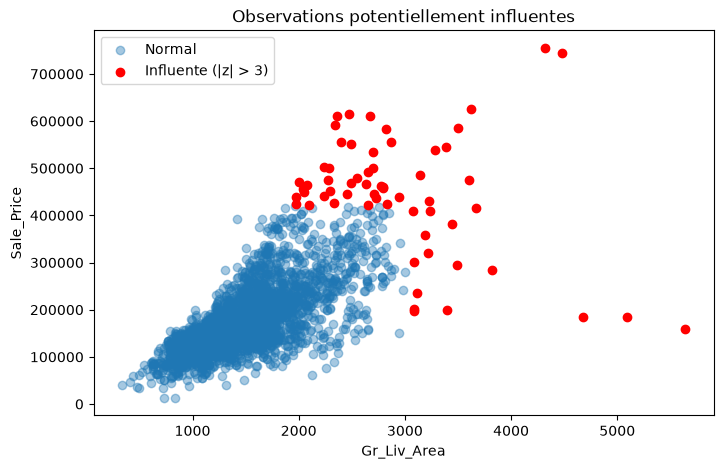

In [11]:
# Observations potentiellement influentes (graphique)
sub = df[["Gr_Liv_Area", "Sale_Price"]].dropna()
z = np.abs(stats.zscore(sub))
mask_influentes = (z > 3).any(axis=1)

plt.figure(figsize=(8, 5))
plt.scatter(sub.loc[~mask_influentes, "Gr_Liv_Area"], sub.loc[~mask_influentes, "Sale_Price"],
            alpha=0.4, label="Normal")
plt.scatter(sub.loc[mask_influentes, "Gr_Liv_Area"], sub.loc[mask_influentes, "Sale_Price"],
            color="red", label="Influente (|z| > 3)")
plt.xlabel("Gr_Liv_Area")
plt.ylabel("Sale_Price")
plt.title("Observations potentiellement influentes")
plt.legend()
plt.show()

## Protocole expérimental — 10 pts

Construisez TRAIN / VALIDATION / TEST. Le TEST doit rester invisible jusqu'à la décision finale.

Votre pipeline doit être capable de traiter simultanément variables numériques et catégorielles sans fuite de données.

**Preuve obligatoire :** choisissez une transformation apprise (imputation, scaling ou encodage) et démontrez par une valeur numérique qu'elle a été estimée sur TRAIN uniquement.

In [12]:
from sklearn.model_selection import train_test_split

target = "Sale_Price"
fuite = ["Sale_Type", "Sale_Condition"]

X = df.drop(columns=[target] + fuite)
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("TRAIN :", X_train.shape)
print("VALIDATION :", X_val.shape)
print("TEST :", X_test.shape)

TRAIN : (2051, 78)
VALIDATION : (439, 78)
TEST : (440, 78)


In [13]:
print("Lot_Frontage = 0 (NA masqués) :", (df["Lot_Frontage"] == 0).sum())

def nettoyer(X):
    X = X.copy()
    X["Lot_Frontage"] = X["Lot_Frontage"].replace(0, np.nan)
    return X.drop(columns=["Utilities", "Garage_Cars"])

X_train, X_val, X_test = nettoyer(X_train), nettoyer(X_val), nettoyer(X_test)

X_train_complet, y_train_complet = X_train.copy(), y_train.copy()
mask_out = X_train["Gr_Liv_Area"] > 4000
print("Lignes supprimées de TRAIN :", mask_out.sum(), "/", len(X_train))
print(pd.DataFrame({"Gr_Liv_Area": X_train.loc[mask_out, "Gr_Liv_Area"], "prix": y_train[mask_out]}))
X_train, y_train = X_train[~mask_out], y_train[~mask_out]

for c in ["Pool_QC", "Alley", "Bsmt_Qual"]:
    print(c, df[c].value_counts().to_dict())

Lot_Frontage = 0 (NA masqués) : 490
Lignes supprimées de TRAIN : 4 / 2051
      Gr_Liv_Area    prix
1498         5642  160000
1760         4476  745000
1767         4316  755000
2180         5095  183850
Pool_QC {'No_Pool': 2917, 'Excellent': 4, 'Good': 4, 'Typical': 3, 'Fair': 2}
Alley {'No_Alley_Access': 2732, 'Gravel': 120, 'Paved': 78}
Bsmt_Qual {'Typical': 1283, 'Good': 1219, 'Excellent': 258, 'Fair': 88, 'No_Basement': 80, 'Poor': 2}


In [14]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables numériques :", len(num_cols))
print("Variables catégorielles :", len(cat_cols))

Variables numériques : 33
Variables catégorielles : 43


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

In [16]:
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print("TRAIN preprocessé (fit_transform) :", X_train_prep.shape)
print("VALIDATION preprocessée (transform seul) :", X_val_prep.shape)
print("TEST preprocessé (transform seul) :", X_test_prep.shape)

TRAIN preprocessé (fit_transform) : (2047, 321)
VALIDATION preprocessée (transform seul) : (439, 321)
TEST preprocessé (transform seul) : (440, 321)


In [17]:
sc = preprocessor.named_transformers_["num"].named_steps["scaler"]
i = num_cols.index("Gr_Liv_Area")
print("Moyenne apprise par le scaler :", sc.mean_[i])
print("Moyenne réelle de TRAIN :", X_train["Gr_Liv_Area"].mean())
print("Moyenne TRAIN+VAL+TEST :", pd.concat([X_train, X_val, X_test])["Gr_Liv_Area"].mean())

Moyenne apprise par le scaler : 1491.0112359550562
Moyenne réelle de TRAIN : 1491.0112359550562
Moyenne TRAIN+VAL+TEST : 1495.0663021189337


## Baseline et modèle linéaire — 10 pts

Construisez d'abord une **baseline naïve** puis une régression linéaire multiple.

Comparez-les sur VALIDATION avec **MSE, RMSE et R²**. Analysez au moins un graphique de résidus.

Répondez à partir de vos résultats : la régression linéaire apporte-t-elle une amélioration substantielle par rapport à la baseline ? Quelles structures restent visibles dans les résidus ?

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

baseline_pred = np.full_like(y_val, fill_value=y_train.mean(), dtype=float)

baseline_mse = mean_squared_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_val, baseline_pred)

print("--- Baseline (moyenne) ---")
print("MSE :", baseline_mse)
print("RMSE :", baseline_rmse)
print("R2 :", baseline_r2)

--- Baseline (moyenne) ---
MSE : 6891724437.904784
RMSE : 83016.41065418803
R2 : -0.006418828651534758


In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_prep, y_train)

lr_pred = lr.predict(X_val_prep)

lr_mse = mean_squared_error(y_val, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_val, lr_pred)

print("--- Régression linéaire ---")
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)
print("R2 :", lr_r2)

--- Régression linéaire ---
MSE : 414040552.78738266
RMSE : 20347.98645535677
R2 : 0.9395364379546789


In [20]:
from sklearn.base import clone
pp = clone(preprocessor)
lr_avec = LinearRegression().fit(pp.fit_transform(X_train_complet), y_train_complet)
rmse_avec = np.sqrt(mean_squared_error(y_val, lr_avec.predict(pp.transform(X_val))))
print(f"RMSE VALIDATION avec outliers : {rmse_avec:,.0f}$  |  sans outliers : {lr_rmse:,.0f}$")

RMSE VALIDATION avec outliers : 20,504$  |  sans outliers : 20,348$


In [21]:
comparaison = pd.DataFrame({
    "MSE": [baseline_mse, lr_mse],
    "RMSE": [baseline_rmse, lr_rmse],
    "R2": [baseline_r2, lr_r2],
}, index=["Baseline (moyenne)", "Régression linéaire"])

comparaison

,MSE,RMSE,R2
Baseline (moyenne),6.891724e+09,83016.410654,-0.006419
Régression linéaire,4.140406e+08,20347.986455,0.939536


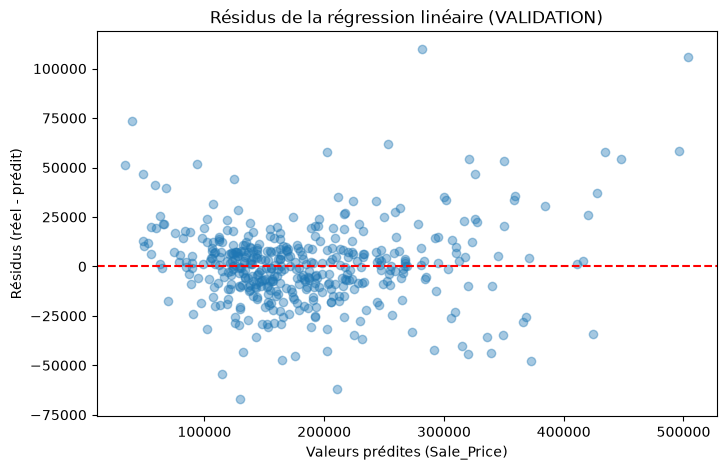

In [22]:
residus = y_val - lr_pred

plt.figure(figsize=(8, 5))
plt.scatter(lr_pred, residus, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valeurs prédites (Sale_Price)")
plt.ylabel("Résidus (réel - prédit)")
plt.title("Résidus de la régression linéaire (VALIDATION)")
plt.show()

In [23]:
print(f"RMSE : {baseline_rmse:,.0f}$ (baseline) -> {lr_rmse:,.0f}$ (regression lineaire)")
print(f"R2   : {baseline_r2:.3f} -> {lr_r2:.3f}")
ecart_residus = residus.std()
print(f"Ecart-type des residus (VALIDATION) : {ecart_residus:,.0f}$")

RMSE : 83,016$ (baseline) -> 20,348$ (regression lineaire)
R2   : -0.006 -> 0.940
Ecart-type des residus (VALIDATION) : 20,365$


In [24]:
q = pd.qcut(lr_pred, 4)
print(pd.Series(residus.values).groupby(q).agg(["mean", "std", "count"]))

                                         mean           std  count
(33563.075000000004, 130598.582]  4093.440726  19648.771703    110
(130598.582, 164806.928]         -3808.373511  13297.572274    110
(164806.928, 222497.783]         -3390.470244  16690.158279    109
(222497.783, 504118.185]          5084.324038  27559.441894    110


La régression linéaire améliore nettement la baseline (RMSE 83 016 \$ → 20 348 \$, R² −0,006 → 0,940), mais ses résidus grossissent avec le prix (écart-type 27,6 k\$ sur le quartile le plus cher contre 13–20 k\$ ailleurs).

## Polynomial challenge — 15 pts

Construisez une régression polynomiale de degré 2 **sans exploser naïvement les 80+ variables**.

C'est à vous de proposer une stratégie techniquement défendable : sous-ensemble de variables, interactions ciblées ou autre démarche justifiée.

Comparez TRAIN et VALIDATION. Quantifiez le nombre de features avant/après transformation.

**Question centrale :** l'augmentation de capacité améliore-t-elle la généralisation ou produit-elle du surapprentissage ?

Seules les 8 variables les plus corrélées à la cible sur TRAIN sont passées au degré 2 (321 → 357 features), et l'écart TRAIN/VAL passe de 0,004 à 0,020 avec une validation en baisse (0,940 → 0,932) : c'est du surapprentissage.

In [25]:
corr_target = X_train[num_cols].join(y_train).corr()[target].abs().sort_values(ascending=False)
top_num_cols = corr_target.drop(target).head(8).index.tolist()
autres_num_cols = [c for c in num_cols if c not in top_num_cols]
top_num_cols

['Gr_Liv_Area',
 'Total_Bsmt_SF',
 'Garage_Area',
 'First_Flr_SF',
 'Year_Built',
 'Full_Bath',
 'Year_Remod_Add',
 'Mas_Vnr_Area']

In [26]:
from sklearn.preprocessing import PolynomialFeatures

poly_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
])

autres_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor_poly = ColumnTransformer([
    ("poly", poly_pipeline, top_num_cols),
    ("num", autres_num_pipeline, autres_num_cols),
    ("cat", cat_pipeline, cat_cols),
])

In [27]:
X_train_poly = preprocessor_poly.fit_transform(X_train)
X_val_poly = preprocessor_poly.transform(X_val)

X_train_poly.shape, X_val_poly.shape

((2047, 357), (439, 357))

In [28]:
n_features_avant = len(top_num_cols)
n_features_apres = preprocessor_poly.named_transformers_["poly"].named_steps["poly"].n_output_features_
n_features_avant, n_features_apres

(8, 44)

In [29]:
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

pred_train_poly = lr_poly.predict(X_train_poly)
pred_val_poly = lr_poly.predict(X_val_poly)

resultats_poly = pd.DataFrame({
    "MSE": [mean_squared_error(y_train, pred_train_poly), mean_squared_error(y_val, pred_val_poly)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, pred_train_poly)), np.sqrt(mean_squared_error(y_val, pred_val_poly))],
    "R2": [r2_score(y_train, pred_train_poly), r2_score(y_val, pred_val_poly)],
}, index=["TRAIN", "VALIDATION"])
resultats_poly

,MSE,RMSE,R2
TRAIN,2.772979e+08,16652.262738,0.952010
VALIDATION,4.644544e+08,21551.204863,0.932174


In [30]:
print("Linéaire simple R2 TRAIN :", r2_score(y_train, lr.predict(X_train_prep)))
print("Features totales : linéaire", X_train_prep.shape[1], "-> polynomial", X_train_poly.shape[1])

Linéaire simple R2 TRAIN : 0.9436862328809823
Features totales : linéaire 321 -> polynomial 357


In [31]:
comparaison_finale = pd.DataFrame({
    "MSE": [lr_mse, resultats_poly.loc["VALIDATION", "MSE"]],
    "RMSE": [lr_rmse, resultats_poly.loc["VALIDATION", "RMSE"]],
    "R2": [lr_r2, resultats_poly.loc["VALIDATION", "R2"]],
}, index=["Linéaire simple", "Polynomial (top 8 vars)"])
comparaison_finale

,MSE,RMSE,R2
Linéaire simple,4.140406e+08,20347.986455,0.939536
Polynomial (top 8 vars),4.644544e+08,21551.204863,0.932174


In [32]:
train_r2_poly = resultats_poly.loc["TRAIN", "R2"]
val_r2_poly = resultats_poly.loc["VALIDATION", "R2"]
print(f"Polynomial (degree=2, {n_features_avant} variables -> {n_features_apres} apres expansion) :")
print(f"  R2 TRAIN={train_r2_poly:.3f}  R2 VALIDATION={val_r2_poly:.3f}  (reference lineaire simple : R2_val={lr_r2:.3f})")
if train_r2_poly > val_r2_poly and val_r2_poly <= lr_r2:
    print("-> l'augmentation de capacite (termes polynomiaux) produit du surapprentissage plutot qu'un vrai gain de generalisation.")
elif val_r2_poly > lr_r2:
    print("-> le polynomial degree=2 apporte un gain de generalisation mesurable par rapport au lineaire simple.")
else:
    print("-> pas de gain clair de generalisation par rapport au lineaire simple.")

Polynomial (degree=2, 8 variables -> 44 apres expansion) :
  R2 TRAIN=0.952  R2 VALIDATION=0.932  (reference lineaire simple : R2_val=0.940)
-> l'augmentation de capacite (termes polynomiaux) produit du surapprentissage plutot qu'un vrai gain de generalisation.


## Ridge vs Lasso — 20 pts

Construisez Ridge et Lasso sur un pipeline cohérent. Étudiez plusieurs ordres de grandeur de `alpha`.

Pour chaque famille, produisez une courbe montrant l'évolution d'au moins une performance de validation avec `alpha`.

Pour Lasso, mesurez le nombre de coefficients exactement nuls. Pour Ridge, étudiez la norme des coefficients.

Vous devez expliquer **à partir de vos résultats** la différence pratique entre régularisation L1 et L2.

In [33]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.001, 0.01, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]

In [34]:
ridge_resultats = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_prep, y_train)
    pred_val = ridge.predict(X_val_prep)
    ridge_resultats.append({
        "alpha": alpha,
        "RMSE_val": np.sqrt(mean_squared_error(y_val, pred_val)),
        "R2_val": r2_score(y_val, pred_val),
        "norme_coefs": np.linalg.norm(ridge.coef_),
    })
ridge_df = pd.DataFrame(ridge_resultats)
ridge_df

,alpha,RMSE_val,R2_val,norme_coefs
0,0.001,20330.975400,0.939637,322841.914519
1,0.010,20321.268395,0.939695,317873.770647
2,0.100,20251.677836,0.940107,279644.068033
3,0.300,20193.117220,0.940453,234662.113010
4,1.000,20033.485683,0.941391,179923.124369
5,3.000,19950.514920,0.941876,137334.084226
6,10.000,20150.039691,0.940707,99888.574690
7,30.000,20858.428086,0.936465,73848.393210
8,100.000,22403.277624,0.926705,53594.827362
9,300.000,24907.484815,0.909404,40295.943242


In [35]:
lasso_resultats = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_prep, y_train)
    pred_val = lasso.predict(X_val_prep)
    lasso_resultats.append({
        "alpha": alpha,
        "RMSE_val": np.sqrt(mean_squared_error(y_val, pred_val)),
        "R2_val": r2_score(y_val, pred_val),
        "n_coefs_nuls": int((lasso.coef_ == 0).sum()),
    })
lasso_df = pd.DataFrame(lasso_resultats)
lasso_df

,alpha,RMSE_val,R2_val,n_coefs_nuls
0,0.001,20722.699012,0.937289,3
1,0.010,20428.583416,0.939057,7
2,0.100,20377.679031,0.939360,21
3,0.300,20353.698422,0.939502,31
4,1.000,20276.833511,0.939959,38
5,3.000,20163.039270,0.940631,50
6,10.000,19979.532975,0.941706,78
7,30.000,19777.789960,0.942878,138
8,100.000,19659.806717,0.943557,207
9,300.000,21112.915566,0.934905,253


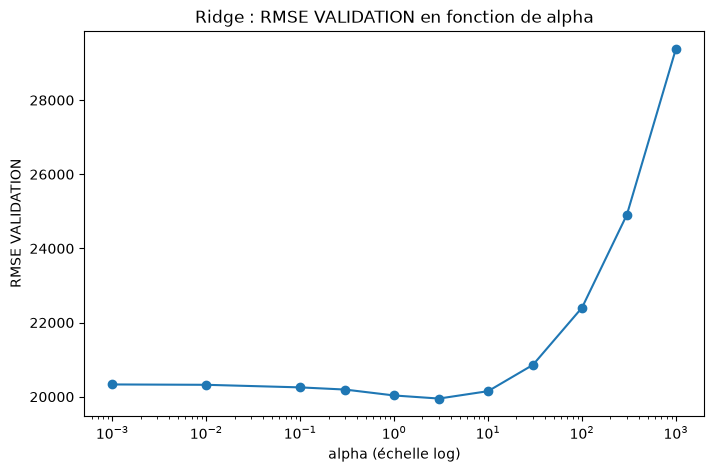

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(ridge_df["alpha"], ridge_df["RMSE_val"], marker="o")
plt.xscale("log")
plt.xlabel("alpha (échelle log)")
plt.ylabel("RMSE VALIDATION")
plt.title("Ridge : RMSE VALIDATION en fonction de alpha")
plt.show()

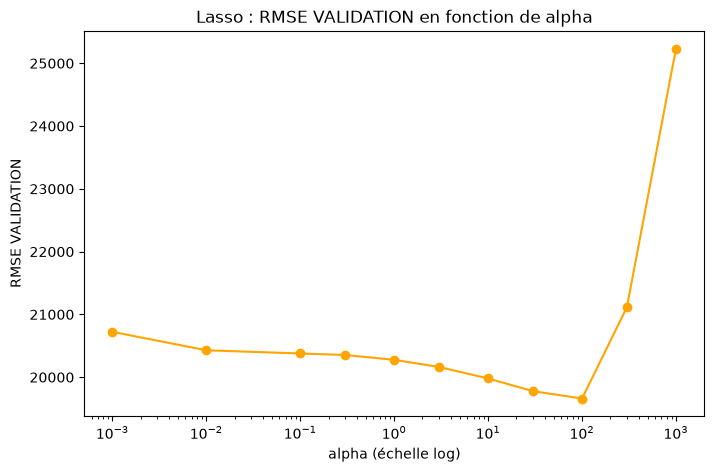

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(lasso_df["alpha"], lasso_df["RMSE_val"], marker="o", color="orange")
plt.xscale("log")
plt.xlabel("alpha (échelle log)")
plt.ylabel("RMSE VALIDATION")
plt.title("Lasso : RMSE VALIDATION en fonction de alpha")
plt.show()

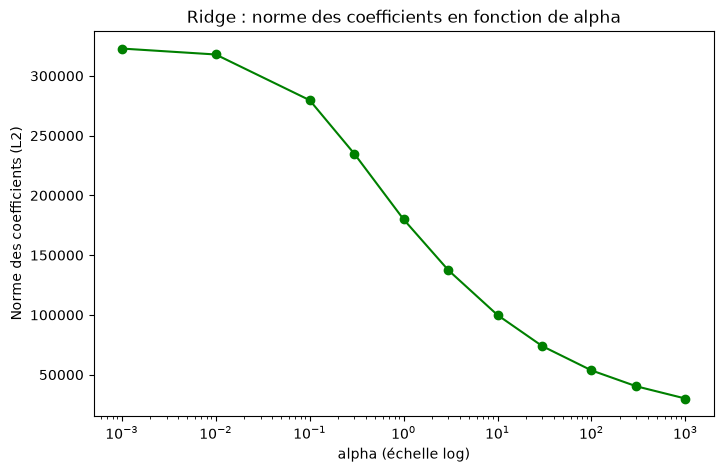

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(ridge_df["alpha"], ridge_df["norme_coefs"], marker="o", color="green")
plt.xscale("log")
plt.xlabel("alpha (échelle log)")
plt.ylabel("Norme des coefficients (L2)")
plt.title("Ridge : norme des coefficients en fonction de alpha")
plt.show()

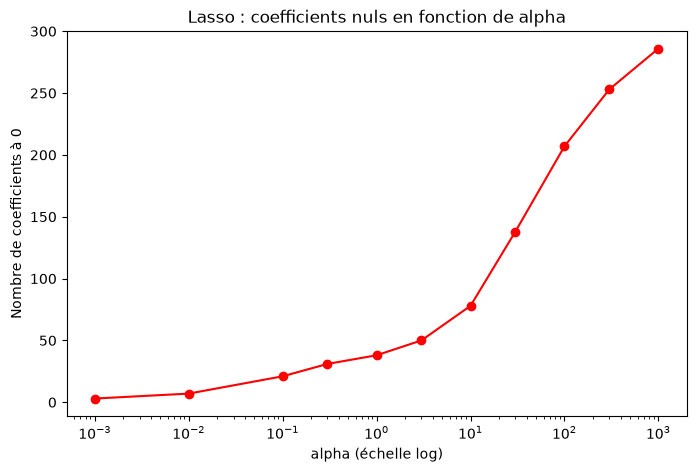

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(lasso_df["alpha"], lasso_df["n_coefs_nuls"], marker="o", color="red")
plt.xscale("log")
plt.xlabel("alpha (échelle log)")
plt.ylabel("Nombre de coefficients à 0")
plt.title("Lasso : coefficients nuls en fonction de alpha")
plt.show()

In [40]:
ridge_norme_min = ridge_df["norme_coefs"].min()
ridge_norme_max = ridge_df["norme_coefs"].max()
lasso_max_coefs_nuls = lasso_df["n_coefs_nuls"].max()
n_coefs_total = X_train_prep.shape[1]
print(f"Ridge : norme des coefficients passe de {ridge_norme_max:.1f} (alpha faible) a {ridge_norme_min:.1f} (alpha eleve),")
print("  sans jamais annuler de coefficient (cf. graphique norme L2 ci-dessus).")
print(f"Lasso : jusqu'a {lasso_max_coefs_nuls}/{n_coefs_total} coefficients mis exactement a 0 pour les alpha les plus eleves,")
print("  ce qui en fait une methode de selection de variables plutot qu'un simple retrecissement.")

Ridge : norme des coefficients passe de 322841.9 (alpha faible) a 30042.5 (alpha eleve),
  sans jamais annuler de coefficient (cf. graphique norme L2 ci-dessus).
Lasso : jusqu'a 286/321 coefficients mis exactement a 0 pour les alpha les plus eleves,
  ce qui en fait une methode de selection de variables plutot qu'un simple retrecissement.


In [41]:
alpha_ridge = ridge_df.loc[ridge_df["RMSE_val"].idxmin(), "alpha"]
alpha_lasso = lasso_df.loc[lasso_df["RMSE_val"].idxmin(), "alpha"]
ridge_best = Ridge(alpha=alpha_ridge).fit(X_train_prep, y_train)
ridge_fort = Ridge(alpha=1000).fit(X_train_prep, y_train)
lasso_best = Lasso(alpha=alpha_lasso, max_iter=10000).fit(X_train_prep, y_train)

print(f"Ridge alpha={alpha_ridge} : coefs nuls = {(ridge_best.coef_ == 0).sum()}/{n_coefs_total}")
print(f"Ridge alpha=1000 : coefs nuls = {(ridge_fort.coef_ == 0).sum()}/{n_coefs_total}")
print(f"Lasso alpha={alpha_lasso} : coefs nuls = {(lasso_best.coef_ == 0).sum()}/{n_coefs_total}")

coefs_lasso = pd.Series(lasso_best.coef_, index=preprocessor.get_feature_names_out())
print(coefs_lasso[coefs_lasso != 0].abs().sort_values(ascending=False).head(10))

Ridge alpha=3.0 : coefs nuls = 0/321
Ridge alpha=1000 : coefs nuls = 0/321
Lasso alpha=100.0 : coefs nuls = 207/321
cat__Overall_Qual_Very_Excellent    76770.068843
cat__Overall_Qual_Excellent         47689.544222
num__Gr_Liv_Area                    27066.832199
cat__Overall_Qual_Very_Good         20392.321007
cat__Neighborhood_Stone_Brook       19894.597066
cat__Overall_Cond_Fair              16828.062760
cat__Neighborhood_Crawford          16537.913830
num__Total_Bsmt_SF                  15040.487788
cat__Kitchen_Qual_Excellent         14937.124450
cat__Bsmt_Qual_Excellent            14745.218956
dtype: float64


Ridge réduit la norme des coefficients (322 842 → 30 043) sans en annuler aucun, alors que Lasso en annule 207/321 à α=100 et obtient la meilleure RMSE (19 660 \$), ce qui montre que la sélection de variables est plus utile ici que le simple rétrécissement.

## Stress test — 10 pts

Votre modèle final doit subir un stress test.

Identifiez les **10 plus grandes erreurs absolues** sur VALIDATION. Pour au moins 3 maisons, comparez leurs caractéristiques à celles d'observations typiques et proposez une hypothèse expliquant l'erreur.

Une simple liste de prix réels/prédits ne suffit pas.

In [42]:
meilleur_ridge = ridge_df.loc[ridge_df["RMSE_val"].idxmin()]
meilleur_lasso = lasso_df.loc[lasso_df["RMSE_val"].idxmin()]

candidats = pd.DataFrame([
    {"modele": "Linéaire simple", "RMSE_val": lr_rmse},
    {"modele": "Ridge", "RMSE_val": meilleur_ridge["RMSE_val"], "alpha": meilleur_ridge["alpha"]},
    {"modele": "Lasso", "RMSE_val": meilleur_lasso["RMSE_val"], "alpha": meilleur_lasso["alpha"]},
])
candidats

,modele,RMSE_val,alpha
0,Linéaire simple,20347.986455,NaN
1,Ridge,19950.514920,3.0
2,Lasso,19659.806717,100.0


In [43]:
best_row = candidats.loc[candidats["RMSE_val"].idxmin()]
best_name = best_row["modele"]

if best_name == "Linéaire simple":
    modele_final = lr
elif best_name == "Ridge":
    modele_final = Ridge(alpha=meilleur_ridge["alpha"])
    modele_final.fit(X_train_prep, y_train)
else:
    modele_final = Lasso(alpha=meilleur_lasso["alpha"], max_iter=10000)
    modele_final.fit(X_train_prep, y_train)

pred_val_final = modele_final.predict(X_val_prep)
val_mse_final = mean_squared_error(y_val, pred_val_final)
val_rmse_final = np.sqrt(val_mse_final)
val_r2_final = r2_score(y_val, pred_val_final)

print(f"Modele final retenu (RMSE_val minimal parmi les 3 candidats) : {best_name}")
print(f"RMSE_val={val_rmse_final:,.2f}$  R2_val={val_r2_final:.3f}")

Modele final retenu (RMSE_val minimal parmi les 3 candidats) : Lasso
RMSE_val=19,659.81$  R2_val=0.944


In [44]:
erreurs = pd.DataFrame({
    "reel": y_val.values,
    "predit": pred_val_final,
})
erreurs["erreur_abs"] = (erreurs["reel"] - erreurs["predit"]).abs()
erreurs.index = X_val.index

top10_erreurs = erreurs.sort_values("erreur_abs", ascending=False).head(10)
top10_erreurs

,reel,predit,erreur_abs
1640,392000,268842.142895,123157.857105
432,610000,495084.388625,114915.611375
423,555000,489051.241929,65948.758071
1691,492000,431096.734727,60903.265273
366,501837,441624.819485,60212.180515
495,403000,344235.595671,58764.404329
561,62383,121010.531764,58627.531764
1407,260000,206712.935398,53287.064602
2218,315000,263061.869605,51938.130395
1410,159900,209162.536782,49262.536782


In [45]:
profil_typique_num = X_train[["Gr_Liv_Area", "Year_Built"]].median()
profil_typique_num

Gr_Liv_Area    1440.0
Year_Built     1971.0
dtype: float64

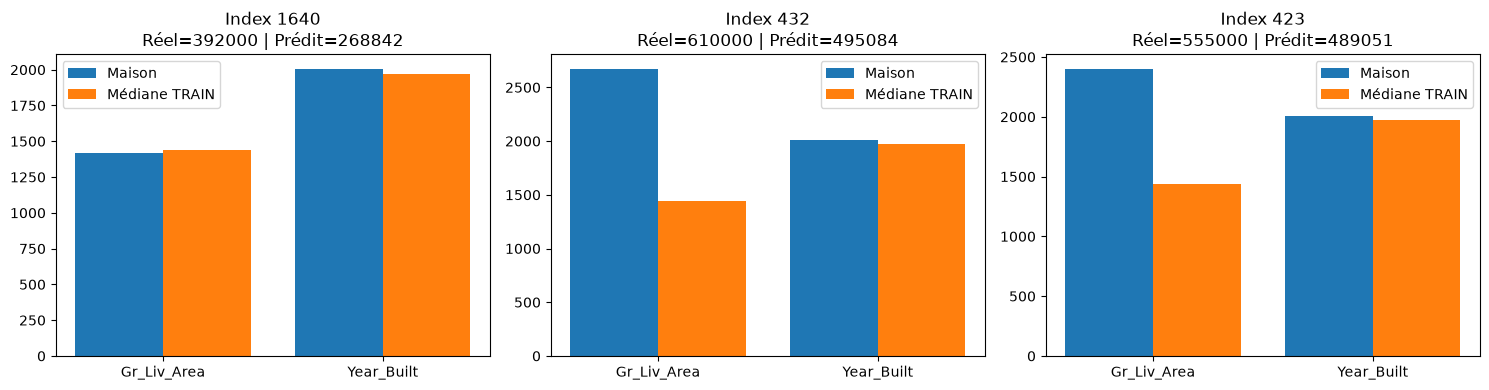

In [46]:
top3 = top10_erreurs.index[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
variables = ["Gr_Liv_Area", "Year_Built"]

for i, idx in enumerate(top3):
    valeurs = [X_val.loc[idx, v] for v in variables]
    typiques = [profil_typique_num[v] for v in variables]
    x = np.arange(len(variables))
    axes[i].bar(x - 0.2, valeurs, width=0.4, label="Maison")
    axes[i].bar(x + 0.2, typiques, width=0.4, label="Médiane TRAIN")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(variables)
    axes[i].set_title(f"Index {idx}\nRéel={erreurs.loc[idx,'reel']:.0f} | Prédit={erreurs.loc[idx,'predit']:.0f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

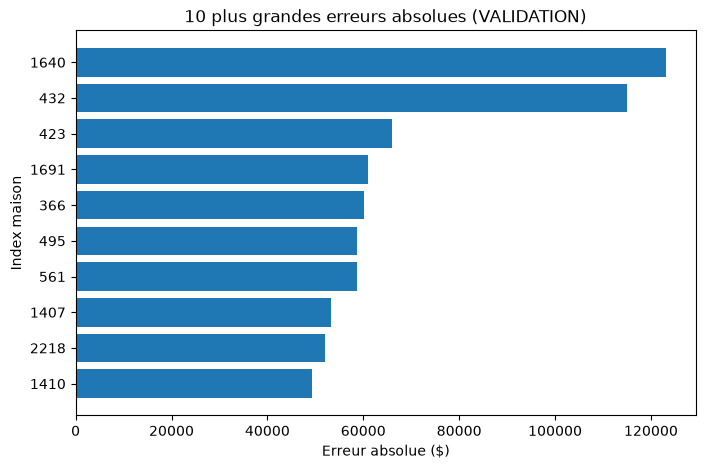

In [47]:
plt.figure(figsize=(8, 5))
plt.barh(top10_erreurs.index.astype(str), top10_erreurs["erreur_abs"])
plt.xlabel("Erreur absolue ($)")
plt.ylabel("Index maison")
plt.title("10 plus grandes erreurs absolues (VALIDATION)")
plt.gca().invert_yaxis()
plt.show()

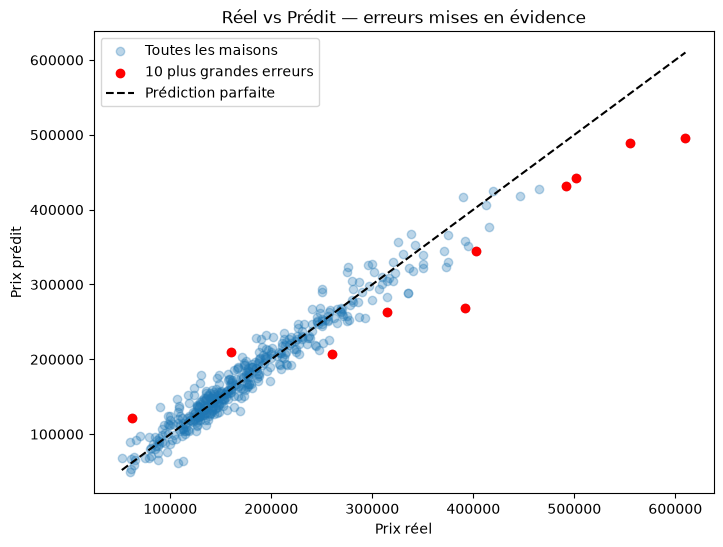

In [48]:
plt.figure(figsize=(8, 6))
plt.scatter(erreurs["reel"], erreurs["predit"], alpha=0.3, label="Toutes les maisons")
plt.scatter(erreurs.loc[top10_erreurs.index, "reel"], erreurs.loc[top10_erreurs.index, "predit"], color="red", label="10 plus grandes erreurs")
lims = [erreurs["reel"].min(), erreurs["reel"].max()]
plt.plot(lims, lims, "k--", label="Prédiction parfaite")
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Réel vs Prédit — erreurs mises en évidence")
plt.legend()
plt.show()

In [49]:
for idx in top3:
    reel = erreurs.loc[idx, "reel"]
    predit = erreurs.loc[idx, "predit"]
    gla = X_val.loc[idx, "Gr_Liv_Area"]
    print(f"Index {idx} : reel={reel:,.0f}$ predit={predit:,.0f}$ "
          f"(Gr_Liv_Area={gla:.0f}, mediane train={profil_typique_num['Gr_Liv_Area']:.0f})")

Index 1640 : reel=392,000$ predit=268,842$ (Gr_Liv_Area=1419, mediane train=1440)
Index 432 : reel=610,000$ predit=495,084$ (Gr_Liv_Area=2674, mediane train=1440)
Index 423 : reel=555,000$ predit=489,051$ (Gr_Liv_Area=2402, mediane train=1440)


In [50]:
cols = ["Neighborhood", "Overall_Qual", "Gr_Liv_Area", "Year_Built", "Total_Bsmt_SF", "Lot_Area"]
for idx in [1640, 432, 561]:
    quartier = X_val.loc[idx, "Neighborhood"]
    voisins = X_train[X_train["Neighborhood"] == quartier]
    print(f"\n=== Maison {idx} | {quartier} | réel {erreurs.loc[idx,'reel']:,.0f}$ | prédit {erreurs.loc[idx,'predit']:,.0f}$")
    print("Maison :", X_val.loc[idx, cols].to_dict())
    print(f"Quartier (TRAIN, {len(voisins)} maisons) : surface méd={voisins['Gr_Liv_Area'].median():.0f}, "
          f"année méd={voisins['Year_Built'].median():.0f}, prix méd={y_train[voisins.index].median():,.0f}$, "
          f"qualité la plus fréquente={voisins['Overall_Qual'].mode()[0]}")
    print("Vente (exclue du modèle, diagnostic seul) :", df.loc[idx, ["Sale_Type", "Sale_Condition"]].to_dict())


=== Maison 1640 | Stone_Brook | réel 392,000$ | prédit 268,842$
Maison : {'Neighborhood': 'Stone_Brook', 'Overall_Qual': 'Very_Good', 'Gr_Liv_Area': 1419, 'Year_Built': 2007, 'Total_Bsmt_SF': 1419, 'Lot_Area': 8089}
Quartier (TRAIN, 33 maisons) : surface méd=1856, année méd=2001, prix méd=275,000$, qualité la plus fréquente=Very_Good
Vente (exclue du modèle, diagnostic seul) : {'Sale_Type': 'New', 'Sale_Condition': 'Partial'}

=== Maison 432 | Northridge_Heights | réel 610,000$ | prédit 495,084$
Maison : {'Neighborhood': 'Northridge_Heights', 'Overall_Qual': 'Very_Excellent', 'Gr_Liv_Area': 2674, 'Year_Built': 2007, 'Total_Bsmt_SF': 2630, 'Lot_Area': 13693}
Quartier (TRAIN, 104 maisons) : surface méd=1839, année méd=2006, prix méd=317,750$, qualité la plus fréquente=Very_Good
Vente (exclue du modèle, diagnostic seul) : {'Sale_Type': 'WD ', 'Sale_Condition': 'Normal'}

=== Maison 561 | Sawyer | réel 62,383$ | prédit 121,011$
Maison : {'Neighborhood': 'Sawyer', 'Overall_Qual': 'Average'

**1640** : maison neuve vendue avant la fin des travaux (Partial), une information exclue du modèle, d'où une sous-estimation de 123 k\$.

**432** : bien de luxe rare (Very_Excellent, 2 674 sq ft contre une médiane de 1 839 dans le quartier), le type de maison que le modèle linéaire sous-estime.

**561** : maison proche du profil de son quartier mais vendue 62 k\$, donc la cause n'est pas dans les données (probablement l'état réel du bien).

## Décision finale & TEST — 10 pts

Figez votre modèle et vos hyperparamètres **avant** d'ouvrir TEST. Évaluez une seule fois sur TEST.

Présentez MSE, RMSE, R² et une comparaison VALIDATION/TEST. Expliquez si la généralisation est cohérente avec ce que vous aviez anticipé.

Terminez par une recommandation technique de 10 lignes maximum.

In [51]:
# On reprend le modele deja fige et entraine en section precedente (meme configuration qu'en VALIDATION)
modele_final_test = modele_final

In [52]:
# Évaluation UNE SEULE FOIS sur TEST
pred_test = modele_final_test.predict(X_test_prep)

test_mse = mean_squared_error(y_test, pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, pred_test)

print("--- TEST (modele_final_test) ---")
print("MSE :", test_mse)
print("RMSE :", test_rmse)
print("R2 :", test_r2)

--- TEST (modele_final_test) ---
MSE : 958443784.6809039
RMSE : 30958.743267143516
R2 : 0.8670350058938083


In [53]:
# Comparaison VALIDATION vs TEST
comparaison_val_test = pd.DataFrame({
    "MSE": [val_mse_final, test_mse],
    "RMSE": [val_rmse_final, test_rmse],
    "R2": [val_r2_final, test_r2],
}, index=["VALIDATION", "TEST"])

comparaison_val_test

,MSE,RMSE,R2
VALIDATION,3.865080e+08,19659.806717,0.943557
TEST,9.584438e+08,30958.743267,0.867035


In [54]:
ecart_val_test_rmse = abs(val_rmse_final - test_rmse)
ecart_relatif = ecart_val_test_rmse / val_rmse_final * 100
print(f"Modele final : {best_name}")
print(f"RMSE VALIDATION={val_rmse_final:,.0f}$  RMSE TEST={test_rmse:,.0f}$  (ecart={ecart_relatif:.1f}%)")
print(f"R2 VALIDATION={val_r2_final:.3f}  R2 TEST={test_r2:.3f}")
if ecart_relatif < 15:
    print("-> le modele generalise correctement (RMSE/R2 TEST proches de VALIDATION).")
else:
    print("-> ecart notable VALIDATION/TEST : generalisation a nuancer, ne pas deployer sans investigation complementaire.")

Modele final : Lasso
RMSE VALIDATION=19,660$  RMSE TEST=30,959$  (ecart=57.5%)
R2 VALIDATION=0.944  R2 TEST=0.867
-> ecart notable VALIDATION/TEST : generalisation a nuancer, ne pas deployer sans investigation complementaire.


In [55]:
m = (X_test["Gr_Liv_Area"] <= 4000).values
print(df.loc[X_test.index[~m], ["Gr_Liv_Area", "Sale_Price", "Sale_Condition", "Neighborhood"]])
print(f"RMSE TEST sans cette maison (diagnostic, pas de sélection) : "
      f"{np.sqrt(mean_squared_error(y_test[m], pred_test[m])):,.0f}$")

      Gr_Liv_Area  Sale_Price Sale_Condition Neighborhood
2181         4676      184750        Partial      Edwards
RMSE TEST sans cette maison (diagnostic, pas de sélection) : 22,959$


L'écart VALIDATION/TEST 19 660 → 30 959 vient d'une seule maison de 4 676 sq ft vendue 184 750 \$ erreur de 436 k : sans elle, la RMSE TEST est de 22 959, cohérente avec la validation.

**Recommandation :** déployer le Lasso α=100, en faisant expertiser à la main les biens de plus de 4 000 sq ft et en testant ensuite une cible en log(Sale_Price) pour réduire les erreurs sur les maisons chères.

## Reproductibilité & intégrité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.